In [1]:
import pandas as pd
import numpy as np
import json
import os

In [3]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/test_data_updated_with_psa.json', 'r') as f:
    data = json.load(f)
    
neg_label = [i for i in data['test'] if i['label'] == 0]

In [8]:
print(len(neg_label))
pirads_label = np.array([i['pirads'] for i in neg_label])
print(np.unique(pirads_label, return_counts=True))


13
(array([2., 3., 4., 5.]), array([3, 3, 5, 2]))


### PSA Dataset

In [3]:
data = pd.read_csv("/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/marksheet.csv")
data.head()

,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center
0,10000,1000000,2019-07-02,73,7.7,NaN,55.0,MRBx,0+0,0,0,NO,PCNN
1,10001,1000001,2016-05-27,64,8.7,0.09,102.0,NaN,NaN,NaN,0,NO,RUMC
2,10002,1000002,2021-04-18,58,4.2,0.06,74.0,NaN,NaN,NaN,0,NO,ZGT
3,10003,1000003,2019-04-05,72,13.0,NaN,71.5,SysBx,0+0,0,0,NO,ZGT
4,10004,1000004,2020-10-21,67,8.0,0.10,78.0,SysBx+MRBx,"0+0,0+0","0,0",0,NO,RUMC


In [ ]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated.json', 'r') as f:
    json_data = json.load(f)

new_train =[]    
for i in json_data['train']:
    p_id = i['image'].split('_')[0]
    st_id = i['image'].split('_')[1].split('.')[0]
    row = data[(data["patient_id"] == int(p_id)) & (data["study_id"] == int(st_id))]
    pvol = row['prostate_volume'].iloc[0]
    psa = row['psa'].iloc[0]
    if pd.notna(psa) and psa != "" and pd.notna(pvol) and pvol != "":
        i['psa'] = [psa, pvol]
        new_train.append(i)

print(len(new_train))
print(len(json_data['train']))

new_test =[]    
for i in json_data['test']:
    p_id = i['image'].split('_')[0]
    st_id = i['image'].split('_')[1].split('.')[0]
    row = data[(data["patient_id"] == int(p_id)) & (data["study_id"] == int(st_id))]
    pvol = row['prostate_volume'].iloc[0]
    psa = row['psa'].iloc[0]
    if pd.notna(psa) and psa != "" and pd.notna(pvol) and pvol != "":
        i['psa'] = [psa, pvol]
        new_test.append(i)

print(len(new_test))
print(len(json_data['test']))

json_data['train'] = new_train
json_data['test'] = new_test
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_with_psa.json', 'w') as f:
    json.dump(json_data, f, indent=4)

624
644
152
162


### Test data

In [16]:
test_df = pd.read_excel('/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/anon_data.xlsx')
test_df.head()

,PATIENT_ID,STUDY_ID,MRI_DATE,SCANNER_MANUFACTURER,SCANNER_MODEL,PATIENT_AGE,PSA,PSA_D,PROSTATE_VOLUME,HISTOPATH_TYPE,LESION_PIRADS,LESION_GS
0,1,1,2024-03-14,GE Medical System,SIGNA Voyager air,66,5.80,0.10,61,RP,4,4+4
1,2,2,2023-03-15,Philips Medical System,Achieva dstream,62,15.00,0.68,22,RP,2,5+4
2,3,3,2023-11-24,Siemens Healtineers,Aera,57,15.00,0.24,63,RP,4,4+3
3,4,4,2023-07-20,Siemens Healtineers,Aera,63,6.03,0.12,49,RP,4,4+5
4,5,5,2023-06-08,Siemens Healtineers,Skyra,70,5.47,0.08,65,RP,3,3+3


In [11]:
row

,PATIENT_ID,STUDY_ID,MRI_DATE,SCANNER_MANUFACTURER,SCANNER_MODEL,PATIENT_AGE,PSA,PSA_D,PROSTATE_VOLUME,HISTOPATH_TYPE,LESION_PIRADS,LESION_GS
39,40,40,2023-07-17,GE Medical System,SIGNA HDxt,60,6.5,0.08,78,RP,4,3+4


In [17]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/test_data_updated.json', 'r') as f:
    json_data = json.load(f)


new_test =[]    
for i in json_data['test']:
    p_id = i['image'].split('.')[0]
    
    row = test_df[(test_df["PATIENT_ID"] == int(p_id)) ]

    pvol = row['PROSTATE_VOLUME'].iloc[0]
    psa = row['PSA'].iloc[0]
    if pd.notna(psa) and psa != "" and pd.notna(pvol) and pvol != "":
        i['psa'] = [float(psa), float(pvol)]
        new_test.append(i)

print(len(new_test))
print(len(json_data['test']))


json_data['test'] = new_test
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/test_data_updated_with_psa.json', 'w') as f:
    json.dump(json_data, f, indent=4)

58
58


### Normalize PSA and PSAD

In [1]:
import argparse
import logging
import os
import shutil
import sys
from pathlib import Path

import torch
import yaml
from monai.utils import set_determinism

from src.data.data_loader import get_dataloader
#from src.model.cspca_model import CSPCAModel
from src.model.mil import MILModel3D
from src.train.train_cspca import train_epoch, val_epoch
from src.utils import get_metrics, save_cspca_checkpoint, setup_logging
import yaml

with open("/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/config/config_cspca_train.yaml", "r") as f:
    cfg = yaml.safe_load(f)
from argparse import Namespace

args = Namespace(**cfg)

In [2]:
args.mode = 'train'
args.project_dir = "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/"
args.checkpoint_cspca = None

args.run_name = "check_dummy"

args.logdir = os.path.join(args.project_dir, "logs", args.run_name)
os.makedirs(args.logdir, exist_ok=True)


if args.dataset_json is None:
    print("Dataset path not provided. Quitting.")
    sys.exit(1)
if args.checkpoint_pirads is None and args.mode == "train":
    print("PI-RADS checkpoint path not provided. Quitting.")
    sys.exit(1)
elif args.checkpoint_cspca is None and args.mode == "test":
    print("csPCa checkpoint path not provided. Quitting.")
    sys.exit(1)

args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if args.device == torch.device("cuda"):
    torch.backends.cudnn.benchmark = True


In [4]:
import json
from sklearn.preprocessing import StandardScaler
args.num_classes =4
args.mil_mode = "att_trans"
mil_model = MILModel3D(num_classes=args.num_classes, mil_mode=args.mil_mode)
cache_dir_path = Path(os.path.join(args.logdir, "cache"))

scaler = StandardScaler()
with open(os.path.join(args.project_dir, "dataset", "PICAI_cspca_updated_with_psa.json")) as f:
    dataset_json = json.load(f)
train_clinical = [i['psa'] for i in dataset_json['train']]
_ = scaler.fit_transform(train_clinical)
args.psa_mean = scaler.mean_.tolist()
args.psa_std = scaler.scale_.tolist()

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)


In [5]:
from __future__ import annotations

import torch
import torch.nn as nn
from monai.utils.module import optional_import

models, _ = optional_import("torchvision.models")


class SimpleNN(nn.Module):
    """
    A simple Multi-Layer Perceptron (MLP) for binary classification.

    This network consists of two hidden layers with ReLU activation and a dropout layer,
    followed by a final sigmoid activation for probability output.

    Args:
        input_dim (int): The number of input features.
    """

    def __init__(self, input_dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 1),
            nn.Sigmoid(),  # since binary classification
        )

    def forward(self, x):
        """
        Forward pass of the classifier.

        Args:
            x (torch.Tensor): Input tensor of shape (Batch, input_dim).

        Returns:
            torch.Tensor: Output probabilities of shape (Batch, 1).
        """
        return self.net(x)


class CSPCAModel(nn.Module):
    """
    Clinically Significant Prostate Cancer (csPCa) risk prediction model using a MIL backbone.

    This model repurposes a pre-trained Multiple Instance Learning (MIL) backbone (originally
    designed for PI-RADS prediction) for binary csPCa risk assessment. It utilizes the
    backbone's feature extractor, transformer, and attention mechanism to aggregate instance-level
    features into a bag-level embedding.

    The original fully connected classification head of the backbone is replaced by a
    custom :class:`SimpleNN` head for the new task.

    Args:
        backbone (nn.Module): A pre-trained MIL model. The backbone must possess the
            following attributes/sub-modules:
            - ``net``: The CNN feature extractor.
            - ``transformer``: A sequence modeling module.
            - ``attention``: An attention mechanism for pooling.
            - ``myfc``: The original fully connected layer (used to determine feature dimensions).

    Attributes:
        fc_cspca (SimpleNN): The new classification head for csPCa prediction.
        backbone: The MIL based PI-RADS classifier.
    """

    def __init__(self, backbone: nn.Module) -> None:
        super().__init__()
        self.backbone = backbone
        
        self.clinical_dim = 2
        self.projection_dim = 16
        self.clinical_projection = nn.Sequential(
            nn.Linear(self.clinical_dim, self.projection_dim),
            nn.ReLU(),
            nn.BatchNorm1d(self.projection_dim) # Helps stabilize the merged scale
        )
        
        self.fc_dim = backbone.myfc.in_features
        self.fc_cspca = SimpleNN(input_dim=self.fc_dim + self.projection_dim) 

    def forward(self, x, psa_data):
        sh = x.shape
        x = x.reshape(sh[0] * sh[1], sh[2], sh[3], sh[4], sh[5])
        x = self.backbone.net(x)
        x = x.reshape(sh[0], sh[1], -1)
        x = x.permute(1, 0, 2)
        x = self.backbone.transformer(x)
        x = x.permute(1, 0, 2)
        a = self.backbone.attention(x)
        a = torch.softmax(a, dim=1)
        x = torch.sum(x * a, dim=1)
        
        psa_features = self.clinical_projection(psa_data)
        x = torch.cat((x, psa_features), dim=1)

        x = self.fc_cspca(x)
        return x


In [7]:

args.use_psa = True
checkpoint = torch.load(args.checkpoint_pirads, weights_only=False, map_location="cpu")
mil_model.load_state_dict(checkpoint["state_dict"])
mil_model = mil_model.to(args.device)
train_loader = get_dataloader(args, split="train")
valid_loader = get_dataloader(args, split="test")
cspca_model = CSPCAModel(backbone=mil_model).to(args.device)

In [8]:
for submodule in [
    cspca_model.backbone.net,
    cspca_model.backbone.myfc,
    cspca_model.backbone.transformer,
]:
    for param in submodule.parameters():
        param.requires_grad = False

args.optim_lr = 1e-4
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cspca_model.parameters()), lr=args.optim_lr
)

In [9]:
import torch
import torch.nn as nn
from monai.metrics import Cumulative, CumulativeAverage
from sklearn.metrics import confusion_matrix, roc_auc_score
old_loss = float("inf")
epoch = 0
cspca_model.train()
criterion = nn.BCELoss()
loss = 0.0
run_loss = CumulativeAverage()
targets_cumulative = Cumulative()
preds_cumulative = Cumulative()

In [11]:
for _, batch_data in enumerate(train_loader):
    data = batch_data["image"].as_subclass(torch.Tensor).to(args.device)
    target = batch_data["label"].as_subclass(torch.Tensor).to(args.device)
    psa_data = batch_data["psa"].as_subclass(torch.Tensor).to(args.device)
    break


In [15]:
optimizer.zero_grad()
output = cspca_model(data, psa_data)
output = output.squeeze(1)
loss = criterion(output, target)
loss.backward()
optimizer.step()

targets_cumulative.extend(target.detach().cpu())
preds_cumulative.extend(output.detach().cpu())
run_loss.append(loss.item())

torch.Size([8])

### Visualise Logs

In [2]:
import re

from collections import defaultdict

train_loss_dict = {}
val_loss_dict = {}
train_auc_dict = {}
val_auc_dict = {}

In [3]:
with open("/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/logs/cspca_train_psa_64/cspca_train_psa_64.log", "r") as f:
    for line in f:
        m = re.search(r"EPOCH (\d+) TRAIN loss: ([0-9.]+) AUC: ([0-9.]+)", line)
        if m:
            e = int(m.group(1))
            train_loss_dict[e] = float(m.group(2))
            train_auc_dict[e] = float(m.group(3))

        m = re.search(r"EPOCH (\d+) VAL loss: ([0-9.]+) AUC: ([0-9.]+)", line)
        if m:
            e = int(m.group(1))
            val_loss_dict[e] = float(m.group(2))
            val_auc_dict[e] = float(m.group(3))

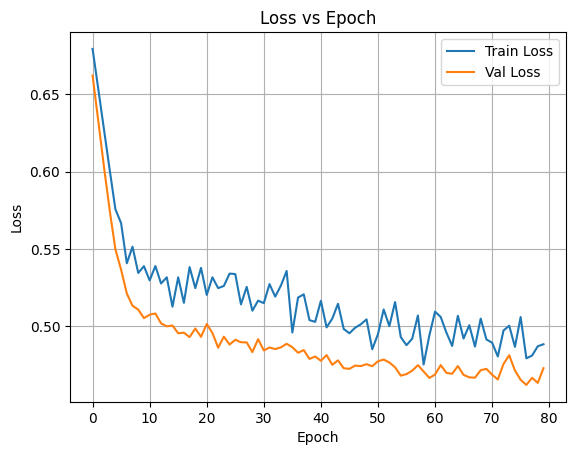

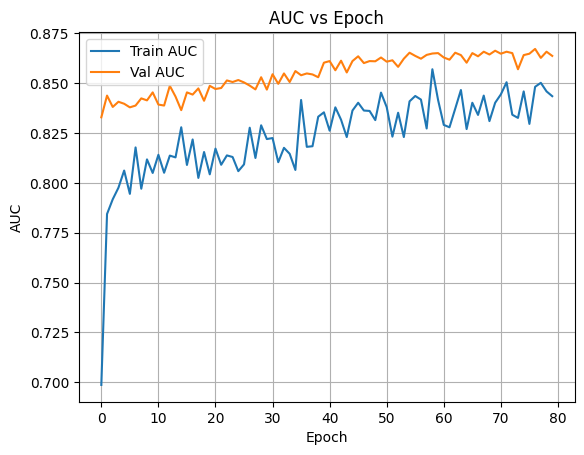

In [4]:
epochs = sorted(train_loss_dict.keys())

train_loss = [train_loss_dict[e] for e in epochs]
val_loss   = [val_loss_dict[e] for e in epochs]
train_auc  = [train_auc_dict[e] for e in epochs]
val_auc    = [val_auc_dict[e] for e in epochs]

import matplotlib.pyplot as plt

# --- Loss ---
plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()
plt.show()

# --- AUC ---
plt.figure()
plt.plot(epochs, train_auc, label="Train AUC")
plt.plot(epochs, val_auc, label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("AUC vs Epoch")
plt.legend()
plt.grid()
plt.show()